Shape: (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


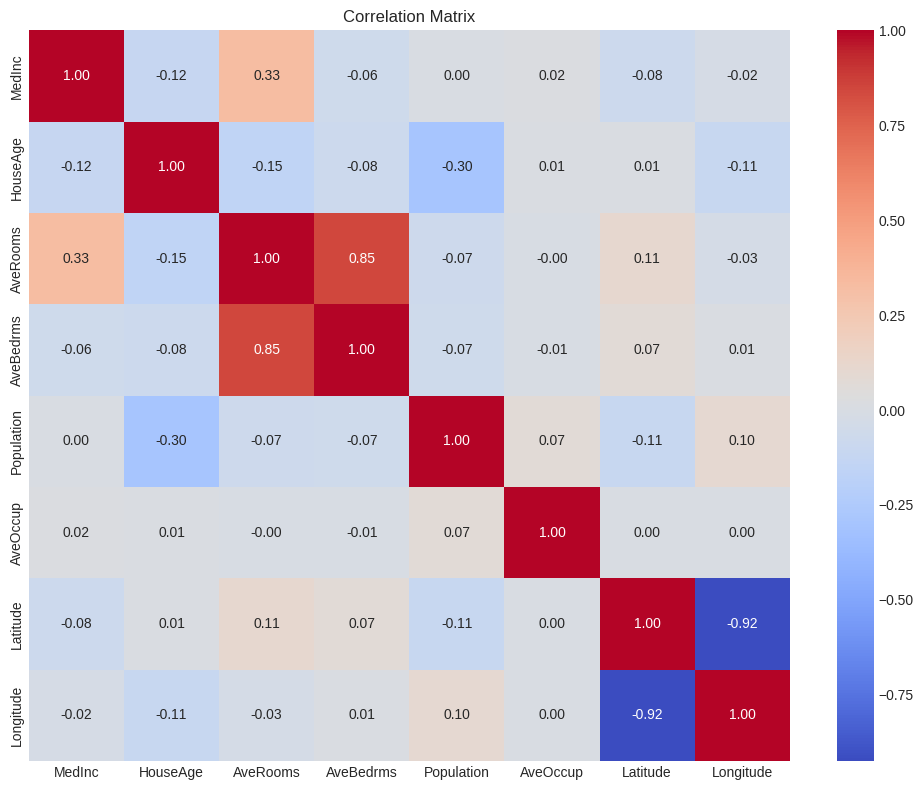

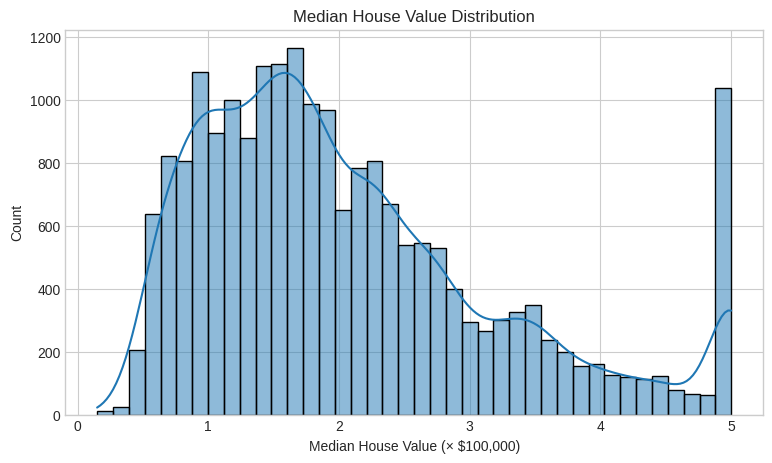

Best k for KNN → 11

Model Performance:

               Model  Train R²  Test R²  Test MAE  Test RMSE
3        k-NN (k=11)    0.7818   0.7219    0.4119     0.6037
0  Linear Regression    0.6647   0.6535    0.4875     0.6738
1              Ridge    0.6647   0.6535    0.4875     0.6738
2              Lasso    0.6608   0.6480    0.4903     0.6792


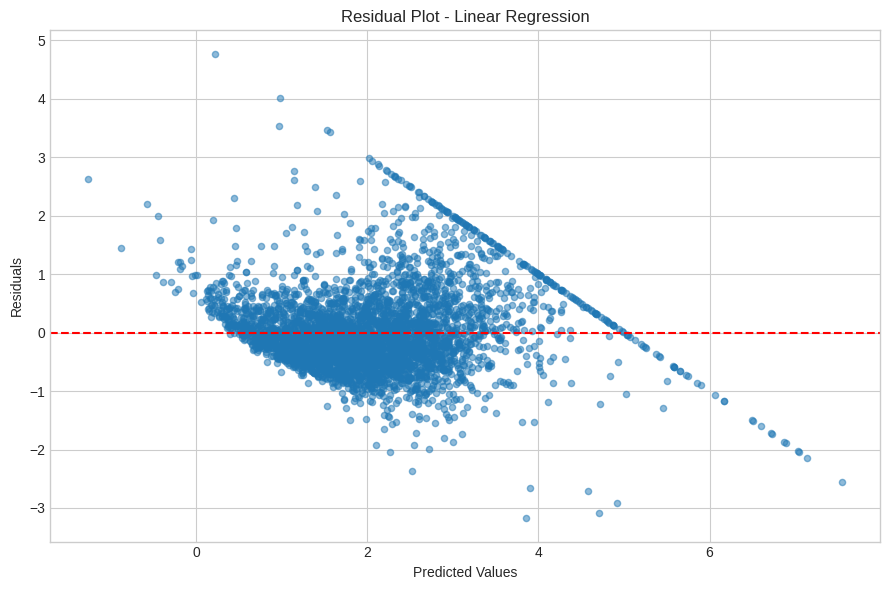

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0c8ff500e1b9b97ebe.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [3]:
# =============================================
# California Housing Price Prediction Project
# =============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ─── Settings ────────────────────────────────────────
np.random.seed(30)
plt.style.use('seaborn-v0_8-whitegrid')

# ─── 1. Load Data ────────────────────────────────────
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

print("Shape:", X.shape)
print("Features:", list(X.columns))

# ─── 2. Quick EDA ────────────────────────────────────
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.histplot(y, kde=True, bins=40)
plt.title("Median House Value Distribution")
plt.xlabel("Median House Value (× $100,000)")
plt.show()

# ─── 3. Feature Engineering ──────────────────────────
X_eng = X.copy()

X_eng['Population_log']     = np.log1p(X_eng['Population'])
X_eng['Rooms_per_HH']       = X_eng['AveRooms'] / X_eng['AveOccup']
X_eng['Bedrooms_per_Room']  = X_eng['AveBedrms'] / X_eng['AveRooms']
X_eng['Population_density'] = X_eng['Population'] / X_eng['AveOccup']

# ─── 4. Train / Test Split & Scaling ─────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_eng, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ─── 5. Models ───────────────────────────────────────
models = {}

# Linear models
models['Linear Regression'] = LinearRegression().fit(X_train_scaled, y_train)
models['Ridge']             = Ridge(alpha=1.0).fit(X_train_scaled, y_train)
models['Lasso']             = Lasso(alpha=0.01).fit(X_train_scaled, y_train)

# kNN with best k
param_grid = {'n_neighbors': range(3, 21, 2)}
grid = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

best_k = grid.best_params_['n_neighbors']
models[f'k-NN (k={best_k})'] = KNeighborsRegressor(n_neighbors=best_k).fit(X_train_scaled, y_train)

print(f"Best k for KNN → {best_k}")

# ─── 6. Evaluation ───────────────────────────────────
def evaluate(name, model):
    pred_train = model.predict(X_train_scaled)
    pred_test  = model.predict(X_test_scaled)

    return {
        'Model'     : name,
        'Train R²'  : round(r2_score(y_train, pred_train), 4),
        'Test R²'   : round(r2_score(y_test, pred_test), 4),
        'Test MAE'  : round(mean_absolute_error(y_test, pred_test), 4),
        'Test RMSE' : round(np.sqrt(mean_squared_error(y_test, pred_test)), 4)
    }

results = [evaluate(name, model) for name, model in models.items()]
results_df = pd.DataFrame(results)
print("\nModel Performance:\n")
print(results_df.sort_values('Test R²', ascending=False))

# ─── 7. Residual Plot (best model) ───────────────────
best_model = models['Linear Regression']   # or choose best one
y_pred = best_model.predict(X_test_scaled)
residuals = y_test - y_pred

plt.figure(figsize=(9, 6))
plt.scatter(y_pred, residuals, alpha=0.5, s=20)
plt.axhline(0, color='red', linestyle='--', lw=1.5)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")
plt.tight_layout()
plt.show()
# ─── Gradio App ──────────────────────────────────────
import gradio as gr

def predict(model_name, MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude):
    feats = [MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude]
    eng_features = [
        np.log1p(Population),
        AveRooms / AveOccup if AveOccup != 0 else 0,
        AveBedrms / AveRooms if AveRooms != 0 else 0,
        Population / AveOccup if AveOccup != 0 else 0
    ]
    input_data = np.array([feats + eng_features])
    input_scaled = scaler.transform(input_data)

    pred = models[model_name].predict(input_scaled)[0]
    return f"Predicted Median House Value: ${pred * 100_000:,.0f}"

demo = gr.Interface(
    fn=predict,
    inputs=[
        gr.Dropdown(choices=list(models.keys()), label="Select Model", value="Linear Regression"),
        gr.Number(label="Median Income (MedInc)"),
        gr.Number(label="House Age"),
        gr.Number(label="Average Rooms"),
        gr.Number(label="Average Bedrooms"),
        gr.Number(label="Population"),
        gr.Number(label="Average Occupancy"),
        gr.Number(label="Latitude"),
        gr.Number(label="Longitude"),
    ],
    outputs="text",
    title="🏠 California House Price Predictor",
    description="ML project using California Housing dataset — try different models!"
)

# Run with share=True to get public link (good for LinkedIn demo)
demo.launch(share=True)   # ← this gives you public URL like xxxx.gradio.live